In [2]:
### Import Libraries

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.metrics import (accuracy_score,
                             classification_report,
                                confusion_matrix,
                                ConfusionMatrixDisplay,
                                f1_score)

In [3]:
# Directories

inpDir = Path('D:\Deep_Learning\SharedData\breast_cancer_mod.csv')
outDir = Path('D:\Deep_Learning\SharedData\breast_cancer_mod_output')

RANDOM_STATE = 24
# np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results
rng = np.random.default_rng(seed=RANDOM_STATE) # Create a random number generator with the specified seed

NOISE = 0.2
EPOCHS = 10001
ALPHA = 0.1
N_SAMPLES = 1000
TEST_SIZE  = 0.2 # Size of test data

# Parameters for plotting
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params)

plt.style.use('seaborn-v0_8-darkgrid')   # plt.style.use('ggplot')

In [4]:
X,y = datasets.make_moons(n_samples=N_SAMPLES,
                          noise=NOISE,
                          shuffle=True,
                          random_state=RANDOM_STATE)
X[:5], y[:5]

(array([[ 0.90633951,  0.90267624],
        [-1.11536828,  0.75579289],
        [ 1.88769158,  0.4175967 ],
        [-0.93345034, -0.02299851],
        [-0.96872877,  0.06396285]]),
 array([0, 0, 1, 0, 0]))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify=y, 
                                                    random_state=RANDOM_STATE,
                                                    test_size=TEST_SIZE)


X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [6]:
def fn_sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [7]:
sm = fn_sigmoid(np.array([[-1,0,1], [-np.inf, 0., np.inf]]))
sm

array([[0.26894142, 0.5       , 0.73105858],
       [0.        , 0.5       , 1.        ]])

# Tanh Activation Function


In [8]:
def fn_activ(z):
    return np.tanh(z)

def fn_activ_prime(z):
    return 1-np.tanh(z)**2

In [9]:
fn_activ(np.array([[-1, 0, 1], [-np.inf, 0., np.inf]]))


array([[-0.76159416,  0.        ,  0.76159416],
       [-1.        ,  0.        ,  1.        ]])

In [10]:
np.tanh(0.5), (1 - np.power(np.tanh(0.5), 2)), fn_activ_prime(0.5)

(np.float64(0.46211715726000974),
 np.float64(0.7864477329659274),
 np.float64(0.7864477329659274))

In [11]:
def fn_predict(model, X_p):
    W1, W2, b1, b2 = model['W1'], model['W2'], model['b1'], model['b2']
    
    z1 = X_p.dot(W1) + b1
    a1 = fn_activ(z1)
        
    z2 = a1.dot(W2) + b2
    a2 = fn_sigmoid(z2)
    
    
    
    return a2 >= 0.5

In [12]:
def fn_calculate_loss(model, X_l, y_l):
    
    W1, W2, b1, b2 = model['W1'], model['W2'], model['b1'], model['b2']
    m = X_l.shape[0]
    
    z1 = X_l.dot(W1) + b1
    a1 = fn_activ(z1)
        
    z2 = a1.dot(W2) + b2
    a2 = fn_sigmoid(z2)
    
    data_loss = - (y_l * np.log(a2) + (1-y_l) * np.log(1 - a2)).sum()
    return data_loss / m

In [20]:
def fn_build_model(nn_hdim, X, y, n_epochs=EPOCHS, alpha=ALPHA):
    m, nn_input_dim = X.shape
    nn_output_dim = y.shape[1]  # output layers dims
    
    W1 = rng.random((nn_input_dim, nn_hdim),
                     dtype=np.float32) / np.sqrt(nn_input_dim)
    
    W2 = rng.random((nn_hdim, nn_output_dim),
                     dtype=np.float32) / np.sqrt(nn_hdim)
    
    b1 = np.zeros((1, nn_hdim), dtype=np.float32)
    
    b2 = np.zeros((1, nn_output_dim), dtype=np.float32)
    
    curr_loss = 0
    loss, epoch = [], []
    
    for i in range(n_epochs):
        ### Forward Propogation
        z1 = X.dot(W1) + b1
        a1 = fn_activ(z1)
        
        z2 = a1.dot(W2) + b2
        a2 = fn_sigmoid(z2)
        
        
        ### Back Prpogation
        dz2 = a2 - y
        assert (z2.shape == dz2.shape), f'Shape Mismatch z2 {z2.shape} and {dz2.shape}'
        
        dW2 = (a1.T).dot(dz2)
        assert (W2.shape == dW2.shape), f'Shape Mismatch z2 {W2.shape} and {dW2.shape}'
        
        db2 = np.sum(dz2, axis = 0, keepdims=True)                                        ### convert dz2 to 1*4 as dz2 is of dimension m*4 and db2 sould be of 1*4
        assert (b2.shape == db2.shape), f'Shape Mismatch z2 {b2.shape} and {db2.shape}'
        
        da1 = dz2.dot(W2.T)
        assert (a1.shape == da1.shape), f'Shape Mismatch z2 {a1.shape} and {da1.shape}'
        
        dz1 = da1 * fn_activ_prime(z1)
        assert (z1.shape == dz1.shape), f'Shape Mismatch z2 {z1.shape} and {dz1.shape}'
        
        dW1 = (X.T).dot(dz1)
        assert (W1.shape == dW1.shape), f'Shape Mismatch z2 {W1.shape} and {dW1.shape}'
        
        db1 = np.sum(dz1, axis = 0, keepdims=True)
        assert (b1.shape == db1.shape), f'Shape Mismatch z2 {b1.shape} and {db1.shape}'
        

        ### Gradient update
        # Elementwise multiplication
        W1 = W1 - alpha * dW1 / m     # dot product will not work here
        W2 = W2 - alpha * dW2 / m 
        b1 = b1 - alpha * db1 / m 
        b2 = b2 - alpha * db2 / m 
        
        
        model = {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}
        
        if i % 100 ==0:
            curr_loss = fn_calculate_loss( model, X, y)
            loss.append(curr_loss)
            epoch.append(i)
            
            if i % 1000 == 0:
                print(f'Loss after Epoch {i} : {curr_loss}')
                
    
    return model , loss , epoch

In [21]:
nn_hdim = 4
y_train = y_train.reshape(-1,1)   # made 2D array
model, loss, epoch = fn_build_model(nn_hdim, X_train, y_train, n_epochs=EPOCHS, alpha=ALPHA)
model

Loss after Epoch 0 : 0.6906590464984664
Loss after Epoch 1000 : 0.294951063948031
Loss after Epoch 2000 : 0.29280773856063647
Loss after Epoch 3000 : 0.2915998780626891
Loss after Epoch 4000 : 0.2889194558539661
Loss after Epoch 5000 : 0.21936487455989467
Loss after Epoch 6000 : 0.15524468537160824
Loss after Epoch 7000 : 0.1277906971962928
Loss after Epoch 8000 : 0.1056603773508935
Loss after Epoch 9000 : 0.08209706461094886
Loss after Epoch 10000 : 0.071241025384113


{'W1': array([[ 1.81055406,  0.58968845,  1.96733448,  3.9833979 ],
        [-1.05392144, -0.56426089, -0.87264617,  2.56030685]]),
 'b1': array([[-2.35304377, -0.0243243 ,  1.11586587, -2.31360551]]),
 'W2': array([[ 4.97776851],
        [ 3.26830829],
        [ 5.14875202],
        [-6.2228039 ]]),
 'b2': array([[-0.24834326]])}

<Axes: xlabel='epochs'>

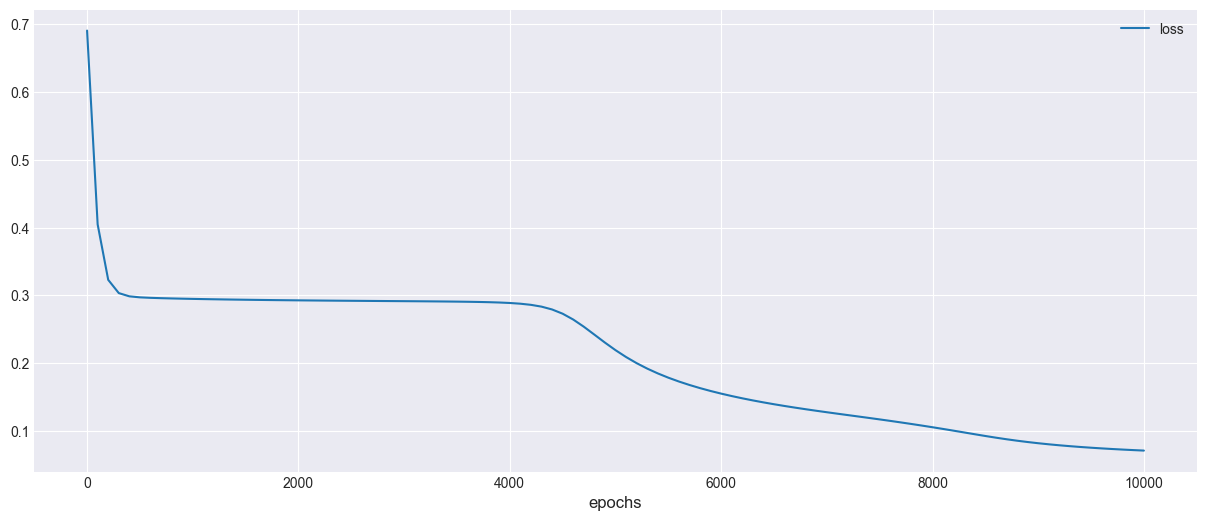

In [23]:
loss_hist = {}
loss_hist['loss'] = loss
loss_hist['epochs'] = epoch
pd.DataFrame(loss_hist).plot(x = 'epochs', y = 'loss')

In [24]:
y_pred = fn_predict(model, X_test)
print('Accuracy score on Test data :', accuracy_score(y_test, y_pred))

Accuracy score on Test data : 0.955


In [ ]:
def fn_plot_decision_boundary(X, wts, pred_func):
    
    fig, ax = plt.subplots(figsize=(8,5))
    
    dm = 0.01
    margin = 10*dm
    
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, dm), 
                         np.arange(y_min, y_max, dm))
    
    # print(xx.shape, yy.shape)
    X_data = np.c_[xx.ravel(), yy.ravel()]
    X_data = np.hstack((X_data, np.ones((X_data.shape[0], 1))))
    
    y_pred = []
    
    for row in X_data:
        a = pred_func(row, wts)
        y_p = 1
        if a < 0.5 : y_p = 0
        y_pred.append(y_p)
        
    Z = np.array(y_pred).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.6, cmap=plt.cm.Paired)
   
    ax.scatter(X[:,0], X[:,1], c=X[:,2], 
               s=20, edgecolor='k', cmap=CMAP)

In [28]:
fn_plot_decision_boundary(model, X_tr = X_train, y_tr = y_train,
                         X_ts = X_test, y_ts = y_test)

TypeError: fn_plot_decision_boundary() got an unexpected keyword argument 'X_tr'